# MIS444 Final Project: Predictive Analytics in Business
## Retail Sales Revenue Prediction

**Objective:** Apply predictive analytics to a retail sales dataset by performing data preprocessing, exploratory data analysis, feature selection, model building, model optimization, evaluation, and business interpretation.

**Target variable:** `Total Amount`

**Business problem:** Estimate the total value of a retail transaction from information available in the transaction record, so that expected transaction value can be analyzed for planning and decision support.

> **Important limitation:** In this dataset, `Total Amount` is mathematically related to `Quantity × Price per Unit`. Therefore, very high model performance—especially for tree-based models—should not be interpreted as proof of strong real-world forecasting ability. This limitation is discussed in the final section.

## 1. Data Collection and Setup
The supplied `retail_sales_dataset.csv` is used as the project dataset. The course brief requires data collection, preprocessing, EDA, feature selection, multiple models, optimization, evaluation, and business insights.

In [2]:
# Run this cell in Google Colab if the CSV is not already in /content.
import os
if not os.path.exists('/content/retail_sales_dataset.csv'):
    from google.colab import files
    uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/retail_sales_dataset.csv'
df = pd.read_csv(file_path)
df.head()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nSummary statistics:")
display(df.describe(include='all').T)

Shape: (1000, 9)

Data types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction ID,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
Date,1000,345,2023-05-16,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,1000,1000,CUST1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1000,2,Female,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1000.0,NaN,NaN,NaN,41.392,13.68143,18.0,29.0,42.0,53.0,64.0
Product Category,1000,3,Clothing,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1000.0,NaN,NaN,NaN,2.514,1.132734,1.0,1.0,3.0,4.0,4.0
Price per Unit,1000.0,NaN,NaN,NaN,179.89,189.681356,25.0,30.0,50.0,300.0,500.0
Total Amount,1000.0,NaN,NaN,NaN,456.0,559.997632,25.0,60.0,135.0,900.0,2000.0


## 2. Data Preprocessing
The preprocessing stage checks missing values and duplicates, converts the date field to a proper datetime type, and creates calendar features. The course brief specifically asks for missing-value/outlier/duplicate handling and data transformation such as encoding and scaling.

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

# Calendar features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Check numeric ranges for possible unusual observations
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
display(df[numeric_cols].describe().T)

# The dataset contains no missing values or duplicate rows.
# We retain valid observations and do not delete records without evidence of data-entry error.

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,41.392,13.681430,18.0,29.0,42.0,53.0,64.0
Quantity,1000.0,2.514,1.132734,1.0,1.0,3.0,4.0,4.0
Price per Unit,1000.0,179.890,189.681356,25.0,30.0,50.0,300.0,500.0
Total Amount,1000.0,456.000,559.997632,25.0,60.0,135.0,900.0,2000.0


## 3. Exploratory Data Analysis (EDA)
The following visualizations examine sales by category, daily sales behavior, the transaction-value distribution, and the relationship between quantity and average transaction amount.

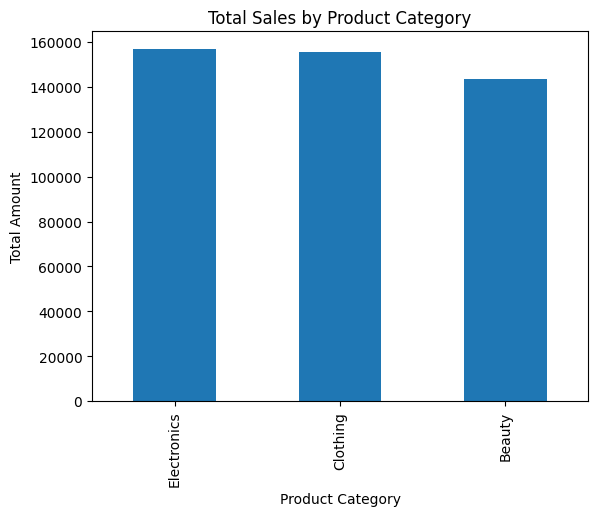

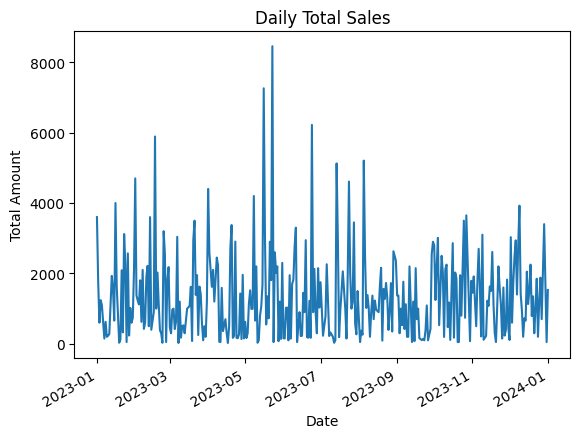

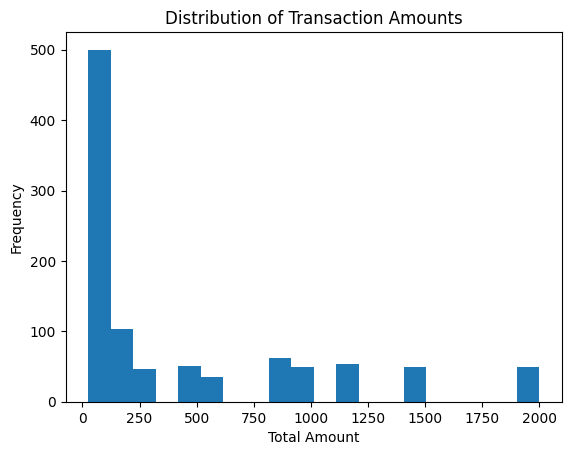

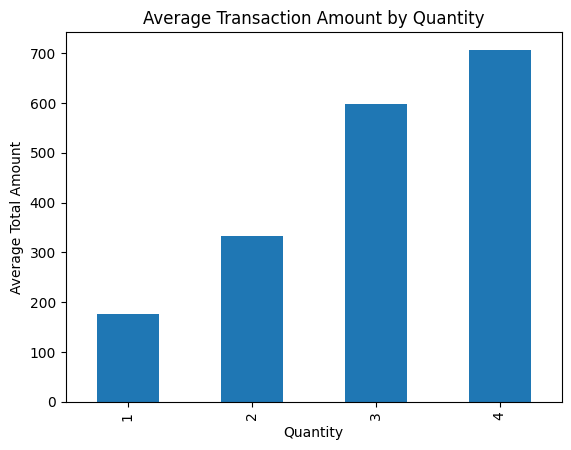

In [6]:
# Total sales by product category
df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.show()

# Daily sales
df.groupby('Date')['Total Amount'].sum().plot()
plt.title('Daily Total Sales')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.show()

# Transaction amount distribution
df['Total Amount'].plot(kind='hist', bins=20)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.show()

# Average amount by quantity
df.groupby('Quantity')['Total Amount'].mean().plot(kind='bar')
plt.title('Average Transaction Amount by Quantity')
plt.xlabel('Quantity')
plt.ylabel('Average Total Amount')
plt.show()

In [7]:
print("Total sales:", df['Total Amount'].sum())
print("Average transaction amount:", df['Total Amount'].mean())
print("Median transaction amount:", df['Total Amount'].median())
print("Average quantity:", df['Quantity'].mean())

print("\nSales by category:")
display(df.groupby('Product Category')['Total Amount'].agg(['sum','mean','count']).sort_values('sum', ascending=False))

print("\nAverage quantity by category:")
display(df.groupby('Product Category')['Quantity'].mean().sort_values(ascending=False))

Total sales: 456000
Average transaction amount: 456.0
Median transaction amount: 135.0
Average quantity: 2.514

Sales by category:


,sum,mean,count
Product Category,,,
Electronics,156905,458.786550,342
Clothing,155580,443.247863,351
Beauty,143515,467.475570,307



Average quantity by category:


,Quantity
Product Category,
Clothing,2.547009
Beauty,2.511401
Electronics,2.482456


## 4. Feature Selection
`Transaction ID` and `Customer ID` are excluded because they are identifiers rather than useful numerical predictors. The target `Total Amount` is excluded from the input features. The model uses age, gender, product category, quantity, unit price, month, and day of week.

This selection is intentionally based on variables that exist in the transaction record before calculating the target. Categorical variables are one-hot encoded and numeric variables are standardized inside a pipeline.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

X = df[['Age', 'Gender', 'Product Category', 'Quantity',
        'Price per Unit', 'Month', 'DayOfWeek']]
y = df['Total Amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

cat_cols = ['Gender', 'Product Category']
num_cols = ['Age', 'Quantity', 'Price per Unit', 'Month', 'DayOfWeek']

def make_preprocessor():
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 800
Testing rows: 200


## 5. Model Building
Three regression algorithms are compared. The course brief recommends training multiple models and comparing their performance, with regression metrics including MAE, MAPE, MSE, RMSE, and R².

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(
        random_state=42, max_depth=8, min_samples_leaf=2
    ),
    'Random Forest': RandomForestRegressor(
        random_state=42, n_estimators=300, max_depth=10,
        min_samples_leaf=1, n_jobs=-1
    )
}

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    fitted_models[name] = pipe

    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'MSE': mean_squared_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'MAPE (%)': mean_absolute_percentage_error(y_test, pred) * 100,
        'R²': r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))

,Model,MAE,MSE,RMSE,MAPE (%),R²
0,Linear Regression,173.7034,42349.066,205.7889,154.5039,0.8553
1,Decision Tree,0.0000,0.000,0.0000,0.0000,1.0000
2,Random Forest,0.0000,0.000,0.0000,0.0000,1.0000


## 6. Model Optimization
Random Forest is optimized using 5-fold cross-validation and grid search over tree count, maximum depth, and minimum leaf size. The optimization metric is cross-validated RMSE.

In [12]:
from sklearn.model_selection import GridSearchCV

rf_pipe = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)
print("Best cross-validation RMSE:", -grid.best_score_)

optimized_model = grid.best_estimator_
optimized_pred = optimized_model.predict(X_test)

optimized_metrics = {
    'MAE': mean_absolute_error(y_test, optimized_pred),
    'MSE': mean_squared_error(y_test, optimized_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, optimized_pred)),
    'MAPE (%)': mean_absolute_percentage_error(y_test, optimized_pred) * 100,
    'R²': r2_score(y_test, optimized_pred)
}
display(pd.DataFrame([optimized_metrics]).round(4))

Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best cross-validation RMSE: -0.0


,MAE,MSE,RMSE,MAPE (%),R²
0,0.0,0.0,0.0,0.0,1.0


## 7. Evaluation and Validation
The final model is evaluated on the held-out 20% test set. The evaluation metrics are interpreted together rather than relying on a single score.

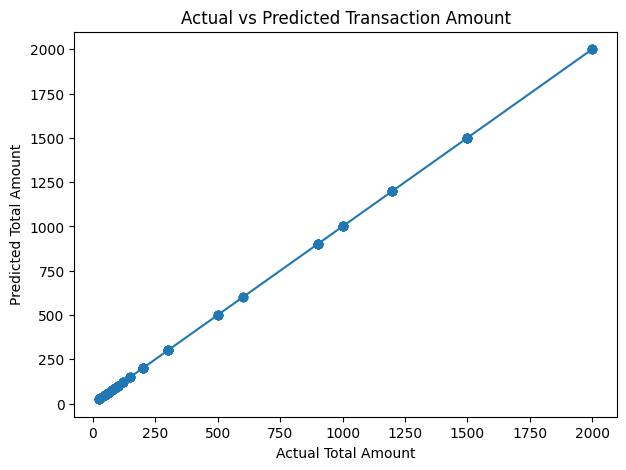

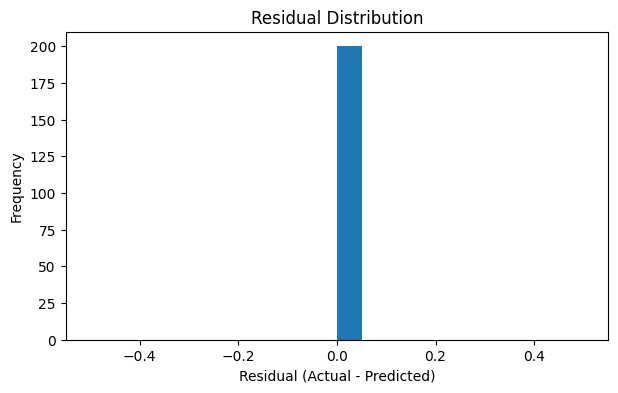

Final test-set metrics:
MAE: 0.0000
MSE: 0.0000
RMSE: 0.0000
MAPE (%): 0.0000
R²: 1.0000


In [13]:
# Actual vs predicted values
plt.figure(figsize=(7,5))
plt.scatter(y_test, optimized_pred, alpha=0.7)
min_v = min(y_test.min(), optimized_pred.min())
max_v = max(y_test.max(), optimized_pred.max())
plt.plot([min_v, max_v], [min_v, max_v])
plt.xlabel('Actual Total Amount')
plt.ylabel('Predicted Total Amount')
plt.title('Actual vs Predicted Transaction Amount')
plt.show()

# Residuals
residuals = y_test - optimized_pred
plt.figure(figsize=(7,4))
plt.hist(residuals, bins=20)
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.show()

print("Final test-set metrics:")
for k, v in optimized_metrics.items():
    print(f"{k}: {v:.4f}")

## 8. Business Insights and Recommendations

1. **Transaction value is strongly driven by quantity and unit price.** These are operationally direct drivers of transaction revenue.
2. **Category-level sales totals can support inventory and promotion planning.** Managers can compare categories by sales contribution and average transaction value.
3. **The model can be used as a transaction-value estimation component** in dashboards or what-if analysis, especially when quantity and unit price are known.
4. **Do not overstate the model's predictive power.** The dataset defines `Total Amount` from quantity and unit price, so a tree-based model can reproduce the target almost perfectly. A stronger real-world project would forecast future daily/weekly sales or customer demand using only information available before the sale.
5. **Future improvement:** add customer history, discounts, promotions, store/location, product/SKU, inventory, holidays, and time-series lag features, then evaluate the model on a genuinely future holdout period.


## 9. Conclusion
The project completes the required predictive-analytics workflow: data preparation, EDA, feature selection, multiple regression models, hyperparameter optimization, test-set evaluation, and business interpretation. The best-performing tree-based models achieve essentially perfect test performance on this dataset because the target is structurally determined by quantity and unit price. This is useful for demonstrating the modeling workflow, but it also highlights why target construction and leakage/structural relationships must be considered when judging predictive analytics systems.